# 01B: Exploratory Data Analysis

Characterises the fleet: site/circuit counts, geographic spread, export limits, key-table schemas, and single-day diagnostic plots.

In [43]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../shared').resolve()))
sys.path.insert(0, str(pathlib.Path('lib').resolve()))

from aws_config import aq, dread, s3_ls
from ciccada_config import SA, SAI, AS4777, TABLES
import explore_plots as ep
import site_selection as ss
import pandas as pd
import numpy as np

## Sites and circuits

In [2]:
# -----------------------------------------------------------------------------
# Assumptions:
# sites  = physical locations (one row per address)
# circuits = monitoring points within a site (one row per phase/device)
# is_pv = True means it's a solar PV circuit (not load, battery, etc.)
# -----------------------------------------------------------------------------

site_count = aq("SELECT count(*) AS n_sites FROM sites", database=SAI)
print("Total sites:", site_count["n_sites"].iloc[0])

Total sites: 41393


In [3]:
circuit_counts = aq("""
    SELECT
        is_pv,
        count(*)          AS n_circuits,
        count(DISTINCT site_id) AS n_sites
    FROM circuits
    GROUP BY is_pv
    ORDER BY is_pv DESC
""", 
database=SAI)
circuit_counts

# is_pv=True rows are what the telemetry analysis is built on.
# The values below double count sites because many sites have both PV and non-PV circuits.

,is_pv,n_circuits,n_sites
0,True,79686,39733
1,False,91725,38191


In [4]:
# How many circuits per site?
circuits_per_site = aq("""
    SELECT
        circuit_count,
        count(*) AS n_sites
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY circuit_count
    ORDER BY circuit_count
""", database=SAI)
circuits_per_site

,circuit_count,n_sites
0,1,22454
1,2,3527
2,3,11556
3,4,432
4,5,51
5,6,1195
6,7,22
7,8,11
8,9,224
9,10,7


## Geographic spread

In [5]:
# -----------------------------------------------------------------------------
# Geographic spread — use meta_up23c, not sites
# -----------------------------------------------------------------------------

states = aq("""
    SELECT state, count(*) AS n_sites
    FROM meta_up23c
    GROUP BY state
    ORDER BY n_sites DESC
""", database=SAI)
states

,state,n_sites
0,NSW,26676
1,QLD,18276
2,VIC,5741
3,SA,4917
4,WA,2452
5,TAS,1086
6,ACT,944
7,NT,478


In [6]:
# -----------------------------------------------------------------------------
# Use partition_lookup (tiny table) rather than querying ts directly.
# Reading min/max timestamps from a billions-row table is expensive;
# the lookup table gives you the answer for free.
# -----------------------------------------------------------------------------

partitions = aq("SELECT * FROM partition_lookup ORDER BY year, month", database=SA)
partitions
# Each row = one (year, month) partition that exists in the ts table.
# The first and last rows tell you the data window.

,year,month,is_pv
0,2024,1,False
1,2024,1,True
2,2024,2,False
3,2024,2,True
4,2024,3,False
5,2024,3,True
6,2024,4,False
7,2024,4,True
8,2024,5,True
9,2024,5,False


In [7]:
unique_months = partitions[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])

print("Data covers:")
print(f"  From: {unique_months['year'].iloc[0]}-{str(unique_months['month'].iloc[0]).zfill(2)}")
print(f"  To:   {unique_months['year'].iloc[-1]}-{str(unique_months['month'].iloc[-1]).zfill(2)}")
print(f"  Total months: {len(unique_months)}")

Data covers:
  From: 2024-01
  To:   2025-06
  Total months: 18


## Export limits (flex_export_detected)

In [8]:
aq('''
SELECT flex_export_detected, count(DISTINCT site_id) AS n_sites
FROM meta_up23c
WHERE is_pv = True
GROUP BY flex_export_detected
''', database='solar_analytics_iceberg')

,flex_export_detected,n_sites
0,False,15609
1,True,539


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# flex_export_detected diagnostic checks
# ═══════════════════════════════════════════════════════════════════════════════

#  Check 1: Where are the flagged sites?
# Break down by state and DNSP to see if flex export is concentrated

flex_by_dnsp = aq("""
    SELECT
        flex_export_detected,
        state,
        dnsp_name,
        count(DISTINCT site_id)  AS n_sites,
        round(avg(ac_capacity_kw), 1) AS avg_ac_kw,
        round(avg(export_limit_kw), 1) AS avg_export_limit_kw
    FROM meta_up23c
    WHERE is_pv = True
    GROUP BY flex_export_detected, state, dnsp_name
    ORDER BY flex_export_detected DESC, n_sites DESC
""", database='solar_analytics_iceberg')

print("Flex-export sites by state and DNSP:")
print(flex_by_dnsp.to_string(index=False))

# Check 2: Do flagged sites have explicit export limits?
# If export_limit_kw is set AND is less than ac_capacity_kw, 
# that's a signal the site really is DOE-constrained.

flex_export_limits = aq("""
    SELECT
        flex_export_detected,
        count(DISTINCT site_id) AS n_sites,
        sum(CASE WHEN export_limit_kw IS NOT NULL THEN 1 ELSE 0 END) AS has_export_limit,
        sum(CASE WHEN export_limit_kw IS NOT NULL
                  AND export_limit_kw < ac_capacity_kw THEN 1 ELSE 0 END)
            AS export_limit_below_nameplate
    FROM (
        SELECT DISTINCT site_id, ac_capacity_kw, export_limit_kw, flex_export_detected
        FROM meta_up23c
        WHERE is_pv = True
    )
    GROUP BY flex_export_detected
""", database='solar_analytics_iceberg')

print("\nExport limit breakdown:")
print(flex_export_limits.to_string(index=False))

Flex-export sites by state and DNSP:
 flex_export_detected state                   dnsp_name  n_sites  avg_ac_kw  avg_export_limit_kw
                 True   QLD                     Energex      150        9.8                  5.3
                 True   QLD                       Ergon      137       10.0                  5.0
                 True   NSW                   Essential       69       14.0                  4.4
                 True   NSW                   Endeavour       30        7.7                  5.6
                 True    SA                        SAPN       28        9.8                  5.0
                 True   NSW                     Ausgrid       22        8.3                  5.0
                 True   VIC                      Ausnet       20        7.9                  3.6
                 True    WA                        <NA>       18        7.8                  1.5
                 True   QLD                     Ausgrid       17        9.7               

## Schema of the key tables

In [11]:
# Schema discovery for all Iceberg tables.

iceberg_tables = [
    "ts",
    "meta_up23c",
    # Stage 1 rebuilds
    "structured_data_v2",
    "all_uncurtailedpv_v2",
    # Stage 2 rebuilds
    "conformance_voltvar_v2",
    "conformance_voltwatt_v2",
    "conformance_voltwattghi_v2",
    # not rebuilt. still legacy
    "conformance_antiisland",
    "conformance_sust_op_3w",
]

schemas = {}
for t in iceberg_tables:
    try:
        row = aq(f"SELECT * FROM {t} LIMIT 1", database=SAI)
        schemas[t] = pd.DataFrame({
            "column": row.columns.tolist(),
            "dtype":  [str(d) for d in row.dtypes.tolist()],
        })
        print(f"OK  {t:32s} {len(row.columns)} columns")
    except Exception as e:
        print(f"ERR {t:32s} {e}")

OK  ts                               16 columns
OK  meta_up23c                       38 columns
OK  structured_data_v2               18 columns
OK  all_uncurtailedpv_v2             11 columns
OK  conformance_voltvar_v2           27 columns
OK  conformance_voltwatt_v2          10 columns
OK  conformance_voltwattghi_v2       14 columns
OK  conformance_antiisland           9 columns
OK  conformance_sust_op_3w           9 columns


In [13]:
# Open up schemas here:
schemas['conformance_voltvar_v2']

,column,dtype
0,site_id,Int64
1,day,Int32
2,day_night,string
3,p_kw_sum,float64
4,nonconformance_voltvar_sum,float64
5,q_adverse_sum,float64
6,q_inactive_sum,float64
7,q_significant_shortfall_sum,float64
8,q_near_conformant_sum,float64
9,q_major_surplus_sum,float64


## Circuit bands

In [14]:
# Circuit count banded: makes the 1-to-60 range interpretable
circuit_profile = aq("""
    SELECT
        CASE
            WHEN circuit_count = 1  THEN '1  - single phase'
            WHEN circuit_count = 2  THEN '2  - split or data gap'
            WHEN circuit_count = 3  THEN '3  - three phase'
            WHEN circuit_count <= 6 THEN '4-6 - multi-array or battery'
            ELSE                         '7+  - commercial / large site'
        END AS circuit_profile,
        count(*) AS n_sites,
        round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY 1
    ORDER BY min(circuit_count)
""", database=SAI)
circuit_profile

,circuit_profile,n_sites,pct
0,1 - single phase,22454,56.5
1,2 - split or data gap,3527,8.9
2,3 - three phase,11556,29.1
3,4-6 - multi-array or battery,1678,4.2
4,7+ - commercial / large site,518,1.3


## Fleet characteristics

In [15]:
# -----------------------------------------------------------------------------
# Site summary four separate queries, one per count
# -----------------------------------------------------------------------------

n_sites         = aq("SELECT count(DISTINCT site_id) AS n FROM sites",       database=SAI)["n"].iloc[0]
n_meta_up23c    = aq("SELECT count(DISTINCT site_id) AS n FROM meta_up23c",  database=SAI)["n"].iloc[0]
n_pv_circuits   = aq("SELECT count(DISTINCT site_id) AS n FROM circuits WHERE is_pv = True", database=SAI)["n"].iloc[0]
#n_single_inv    = aq("SELECT count(*) AS n FROM meta_single_inverters",       database=SA) ["n"].iloc[0]

site_summary = pd.DataFrame([{
    "total_in_sites_table":       n_sites,
    "sites_in_meta_up23c":        n_meta_up23c,
    "sites_with_pv_circuit":      n_pv_circuits
#    "meta_single_inverters_rows": n_single_inv,
}])
site_summary

,total_in_sites_table,sites_in_meta_up23c,sites_with_pv_circuit
0,41393,16148,39733


## Single-day diagnostic plots

Pick a site + date, pull one day, convert to AEST, and plot. Two views:
- `plot_operational`: Volt-Watt + Volt-VAr response
- `plot_protective`: sustained-operation + anti-islanding (over/under-voltage)

In [ ]:
# Rank sites for a mechanism
ranked = ss.rank_sites(
    "voltvar", 
    aq, 
    behaviour="nonconforming",
    year=2024, 
    min_days=20,
    n_results=30)
ranked

NONCONFORMING sites — voltvar  |  period: 2024  |  table: conformance_voltvar_v2
Ranking metric = adverse + inactive + significant_shortfall (R5-correct). all_nc_pct = all NC / total_count.
Returned 30 sites. Top = most nonconforming.


,site_id,nonconf_intervals,total_intervals,n_days,nonconf_pct,nc_adverse,nc_inactive,nc_shortfall,nc_near_conformant,nc_surplus,nc_curtailment,all_nc_pct
0,226126249,105269,105269,732,100.00,105269,0,0,0,0,0,100.00
1,1692756661,104535,104586,732,99.95,104131,404,0,1,48,0,100.00
2,1204318980,104949,105028,732,99.92,104949,0,0,0,79,0,100.00
3,265597836,105042,105144,732,99.90,105042,0,0,0,47,0,99.95
4,994397173,93286,93389,652,99.89,81487,11799,0,0,85,0,99.98
5,1107268862,22771,22814,162,99.81,22771,0,0,0,43,0,100.00
6,1261825340,56686,56822,396,99.76,56686,0,0,0,133,0,99.99
7,987241710,100787,101164,706,99.63,100787,0,0,0,373,0,100.00
8,1042931633,104353,104887,732,99.49,104352,1,0,8,506,0,99.98
9,1868730879,103105,103763,728,99.37,103105,0,0,0,655,0,100.00


In [37]:
# 2. Pull that site nameplate/year/month/polarity
SITE_ID = ranked["site_id"].iloc[1]
df, info = ss.pull_site_telemetry(SITE_ID, "voltvar", aq, year=2024)

Site 1692756661  |  WA / <NA>  |  5.0 kW  |  Generic Inverter 5kW
Data: 2024-01-01 -> 2025-12-31  |  polarity 1
Auto-selected month 6 (of available [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
Rows: 8,526  (2024-06-01 -> 2024-07-01)


In [38]:
# 3. Which day to plot?
ss.suggest_days(df, "voltvar")

No days with V > 258.0 V. Voltage range: 240.6-255.8 V
Falling back to V > 240.0 V:
Days with V > 258.0 V (most first):
t_stamp_aest
2024-06-08    288
2024-06-14    288
2024-06-28    288
2024-06-27    288
2024-06-30    288
2024-06-29    288
2024-06-18    288
2024-06-07    287
2024-06-23    287
2024-06-17    287
2024-06-03    287
2024-06-05    287
2024-06-19    286
2024-06-15    286
2024-06-12    286

  -> best candidate: 2024-06-08  (288 intervals)


t_stamp_aest
2024-06-08    288
2024-06-14    288
2024-06-28    288
2024-06-27    288
2024-06-30    288
2024-06-29    288
2024-06-18    288
2024-06-07    287
2024-06-23    287
2024-06-17    287
2024-06-03    287
2024-06-05    287
2024-06-19    286
2024-06-15    286
2024-06-12    286
2024-06-24    286
2024-06-21    286
2024-06-16    285
2024-06-13    285
2024-06-04    285
2024-06-09    285
2024-06-10    285
2024-06-11    285
2024-06-25    285
2024-06-22    284
2024-06-06    284
2024-06-20    284
2024-06-02    283
2024-06-26    230
2024-06-01    165
2024-07-01    120
Name: voltage, dtype: int64

Month pulled: 2024 6
Dates available: [datetime.date(2024, 6, 1), datetime.date(2024, 6, 2), datetime.date(2024, 6, 3), datetime.date(2024, 6, 4), datetime.date(2024, 6, 5)] ...


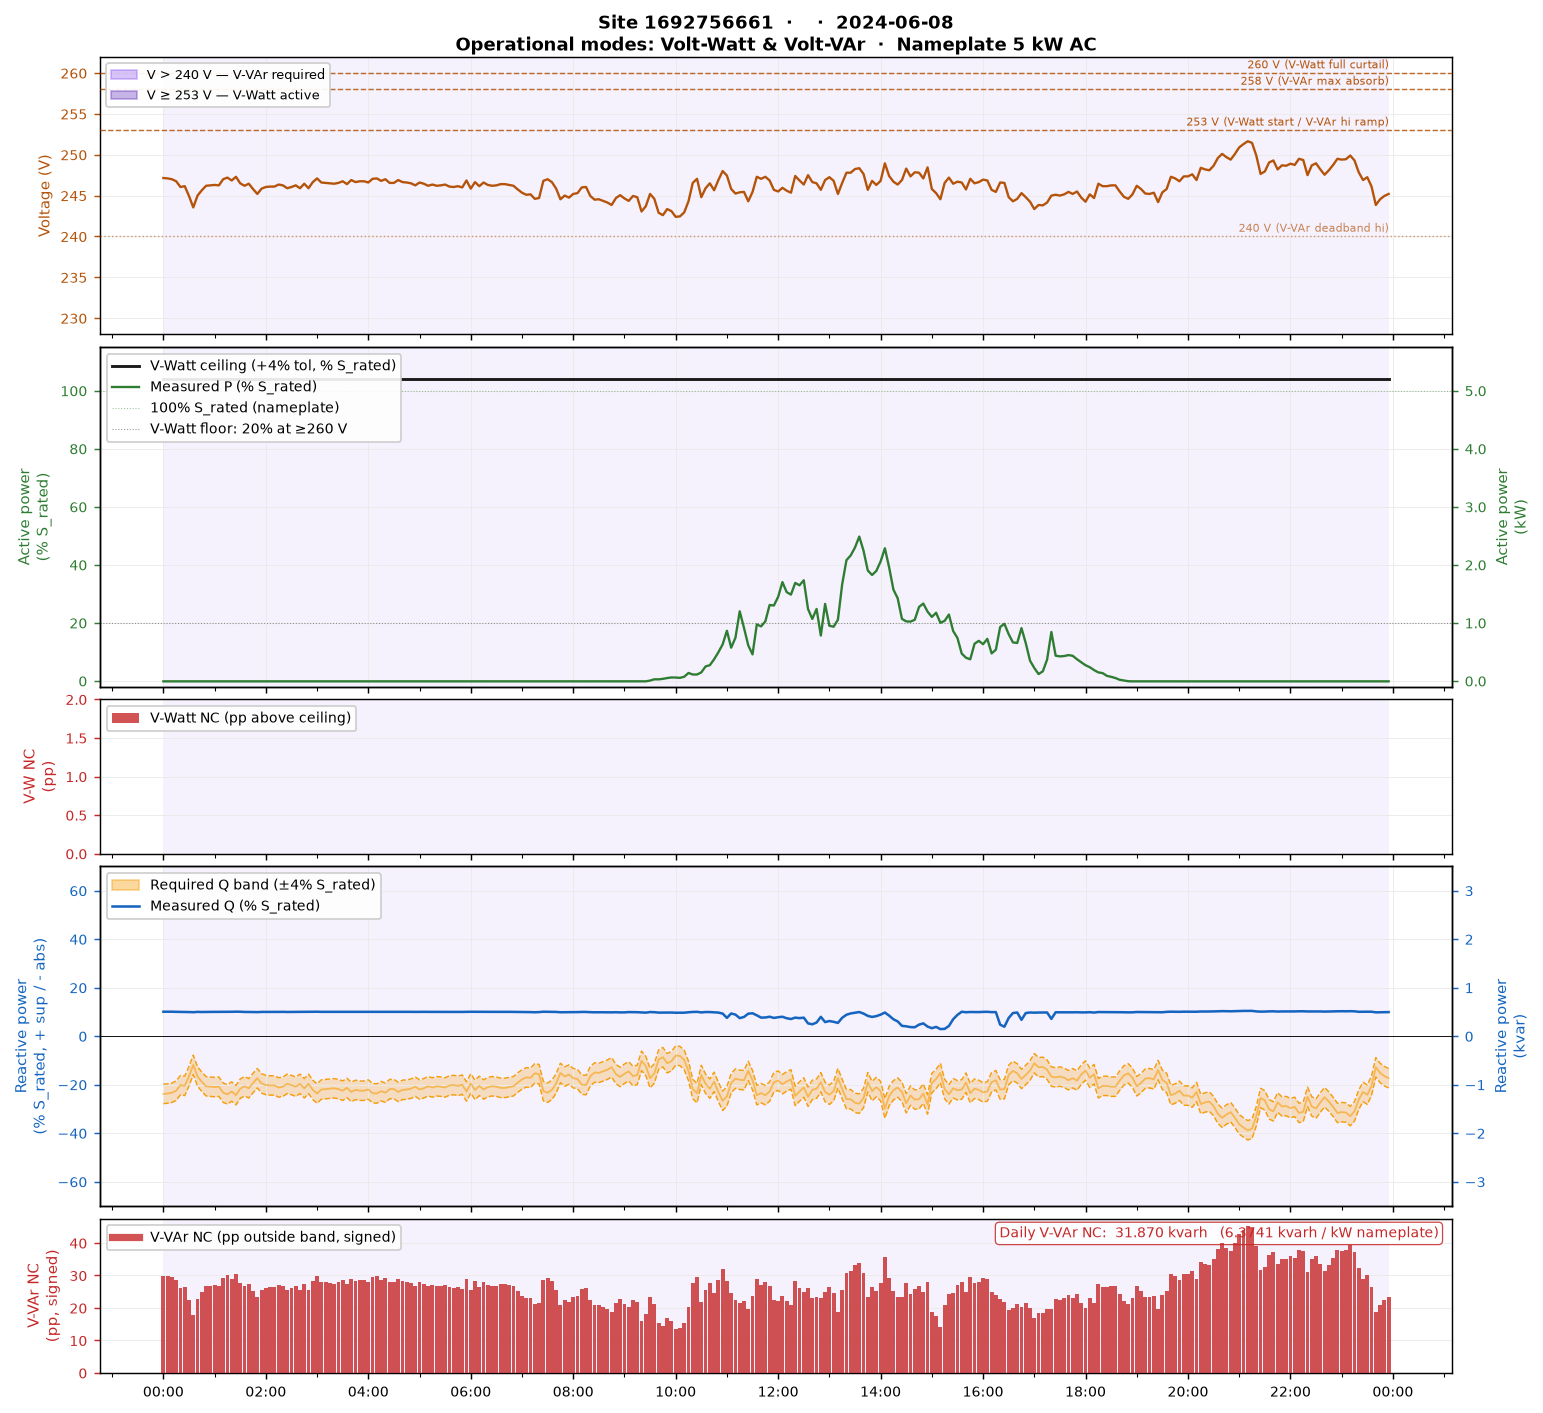


Volt-Watt:  0 non-conforming intervals
Volt-VAr:   288 non-conforming intervals  |  31.870 kvarh  (6.3741 kvarh/kW)


In [40]:
# 4. Plot — pick a date that's actually in df
print("Month pulled:", info["plot_year"], info["plot_month"])
print("Dates available:", sorted(df["t_stamp_aest"].dt.date.unique())[:5], "...")

ZOOM_DATE = "2024-06-08"
df_day = df[df["t_stamp_aest"].dt.date == pd.Timestamp(ZOOM_DATE).date()].copy()
assert len(df_day) > 0, f"No rows for {ZOOM_DATE}. Pick from the dates printed above or from suggest_days()."

ep.plot_operational(df_day, info["site_id"], info["ac_capacity_kw"], ZOOM_DATE, AS4777)

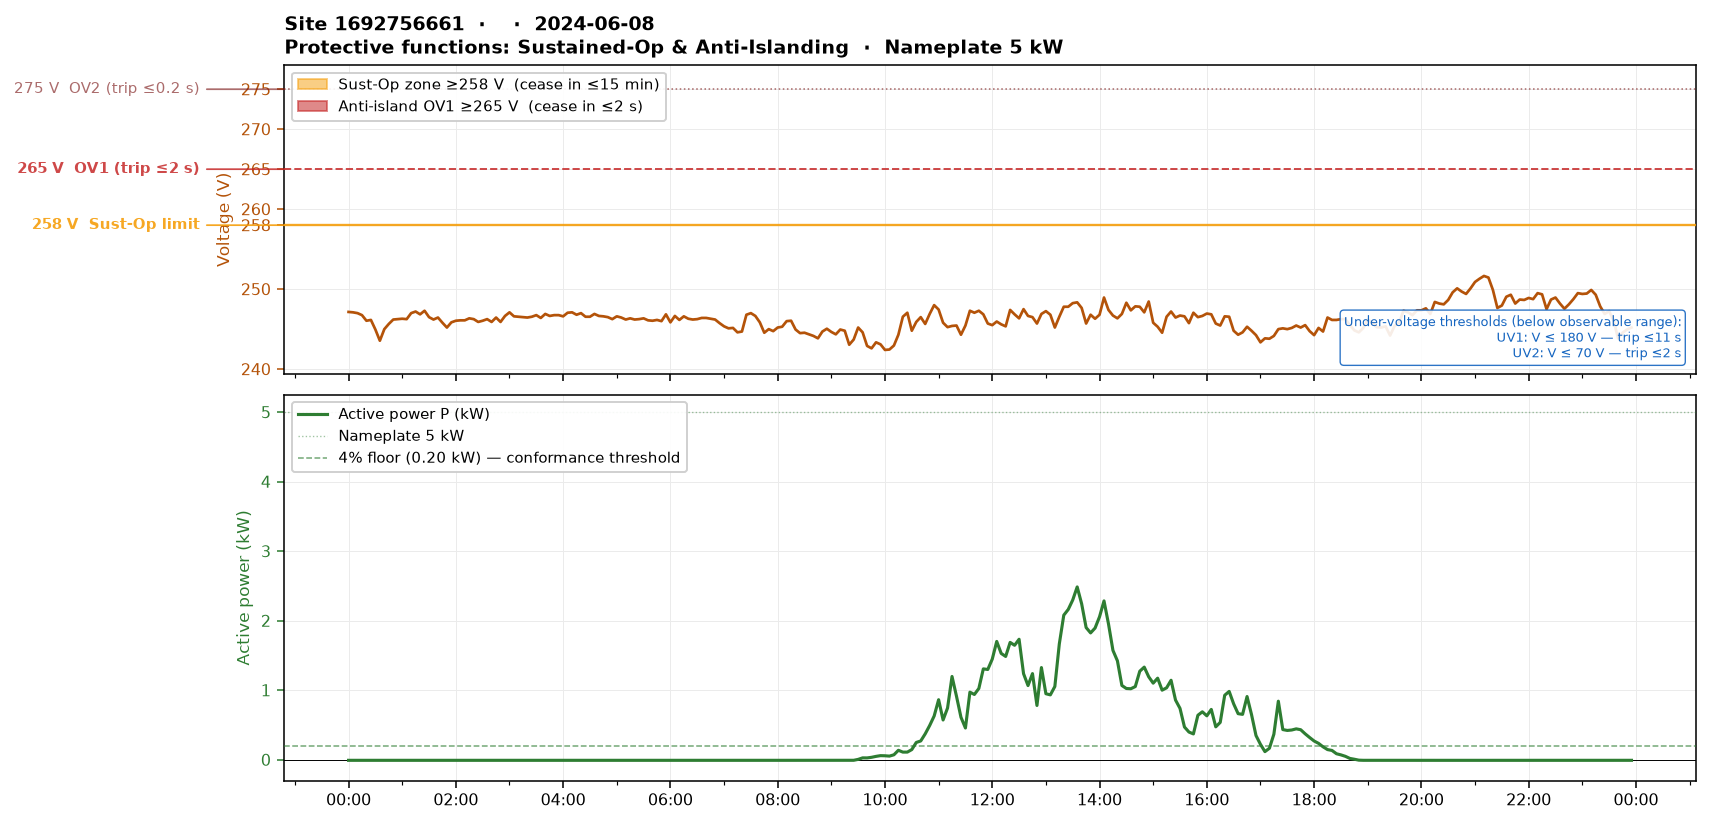

In [41]:
ep.plot_protective(df_day, info["site_id"], info["ac_capacity_kw"], ZOOM_DATE)

In [44]:
# uses the month that pull_site_telemetry resolved
scatter_df = ss.pull_month_scatter(info["site_id"], info["plot_year"],
                                   info["plot_month"], aq)

ep.plot_vvar_month_scatter(scatter_df, info["site_id"], info["ac_capacity_kw"],
                           f"{info['plot_year']}-{info['plot_month']:02d}",
                           manufacturer=info["manufacturer"])

AttributeError: module 'site_selection' has no attribute 'pull_month_scatter'